In [21]:
#kagancankaba200201049
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [22]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

train_images = train_images.reshape(60000, 784) / 255.0
test_images = test_images.reshape(10000, 784) / 255.0

train_labels = np.eye(10)[train_labels]
test_labels = np.eye(10)[test_labels]

print("Eğitim verisi boyutu:", train_images.shape)
print("\nİlk 3 etiketin one-hot encoded hali:\n", train_labels[:3])


Eğitim verisi boyutu: (60000, 784)

İlk 3 etiketin one-hot encoded hali:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [6]:
def initialize_parameters(input_size, hidden_size, output_size):
    np.random.seed(42)
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2. / input_size)
    b1 = np.zeros(hidden_size)
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2. / hidden_size)
    b2 = np.zeros(output_size)
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

parameters = initialize_parameters(784, 128, 10)

print("✅ Parametreler başlatıldı.")
print("W1 boyutu:", parameters["W1"].shape)
print("W2 boyutu:", parameters["W2"].shape)


✅ Parametreler başlatıldı.
W1 boyutu: (784, 128)
W2 boyutu: (128, 10)


In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

print("Sigmoid ve Sigmoid Türevi tanımlandı.")


Sigmoid ve Sigmoid Türevi tanımlandı.


In [10]:
def forward_prop(X, parameters):
    Z1 = np.dot(X, parameters["W1"]) + parameters["b1"]
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, parameters["W2"]) + parameters["b2"]
    A2 = sigmoid(Z2)
    return {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}

sample_output = forward_prop(train_images[:1], parameters)
print("Forward propagation örneği tamamlandı.")
print("Çıkış aktivasyonu (A2) örneği:\n", sample_output["A2"])


Forward propagation örneği tamamlandı.
Çıkış aktivasyonu (A2) örneği:
 [[0.50176692 0.5957095  0.46690013 0.18481233 0.28710432 0.4494456
  0.57975268 0.73296629 0.51652002 0.61818756]]


In [12]:
def compute_loss(A2, Y):
    m = Y.shape[0]
    loss = -np.sum(Y * np.log(A2 + 1e-8)) / m
    return loss

sample_loss = compute_loss(sample_output["A2"], train_labels[:1])
print(f"Örnek için hesaplanan loss: {sample_loss:.5f}")


Örnek için hesaplanan loss: 0.48096


In [13]:
def back_prop(parameters, cache, X, Y):
    m = X.shape[0]
    dZ2 = cache["A2"] - Y
    dW2 = np.dot(cache["A1"].T, dZ2) / m
    db2 = np.sum(dZ2, axis=0) / m
    dA1 = np.dot(dZ2, parameters["W2"].T)
    dZ1 = dA1 * sigmoid_derivative(cache["Z1"])
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0) / m
    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

grads = back_prop(parameters, sample_output, train_images[:1], train_labels[:1])
print("Geri yayılım tamamlandı.")
print("dW1 ortalama değeri:", np.mean(grads["dW1"]))
print("dW2 ortalama değeri:", np.mean(grads["dW2"]))


✅ Geri yayılım tamamlandı.
dW1 ortalama değeri: 0.0010179259268670625
dW2 ortalama değeri: 0.19651553109542574


In [14]:
def update_parameters(parameters, grads, learning_rate=0.1):
    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]
    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]
    return parameters

parameters = update_parameters(parameters, grads)
print("Parametreler güncellendi.")


Parametreler güncellendi.


In [15]:
batch_size = 64
epochs = 10

for epoch in range(epochs):
    for i in range(0, train_images.shape[0], batch_size):
        X_batch = train_images[i:i+batch_size]
        Y_batch = train_labels[i:i+batch_size]
        cache = forward_prop(X_batch, parameters)
        loss = compute_loss(cache["A2"], Y_batch)
        grads = back_prop(parameters, cache, X_batch, Y_batch)
        parameters = update_parameters(parameters, grads, 0.1)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")


Epoch 1/10, Loss: 0.7209
Epoch 2/10, Loss: 0.6075
Epoch 3/10, Loss: 0.5385
Epoch 4/10, Loss: 0.4872
Epoch 5/10, Loss: 0.4458
Epoch 6/10, Loss: 0.4119
Epoch 7/10, Loss: 0.3836
Epoch 8/10, Loss: 0.3601
Epoch 9/10, Loss: 0.3408
Epoch 10/10, Loss: 0.3251


In [16]:
cache_test = forward_prop(test_images, parameters)
predictions = np.argmax(cache_test["A2"], axis=1)
true_labels = np.argmax(test_labels, axis=1)

accuracy = np.mean(predictions == true_labels)
print(f"Test doğruluğu: {accuracy * 100:.2f}%")


Test doğruluğu: 84.75%


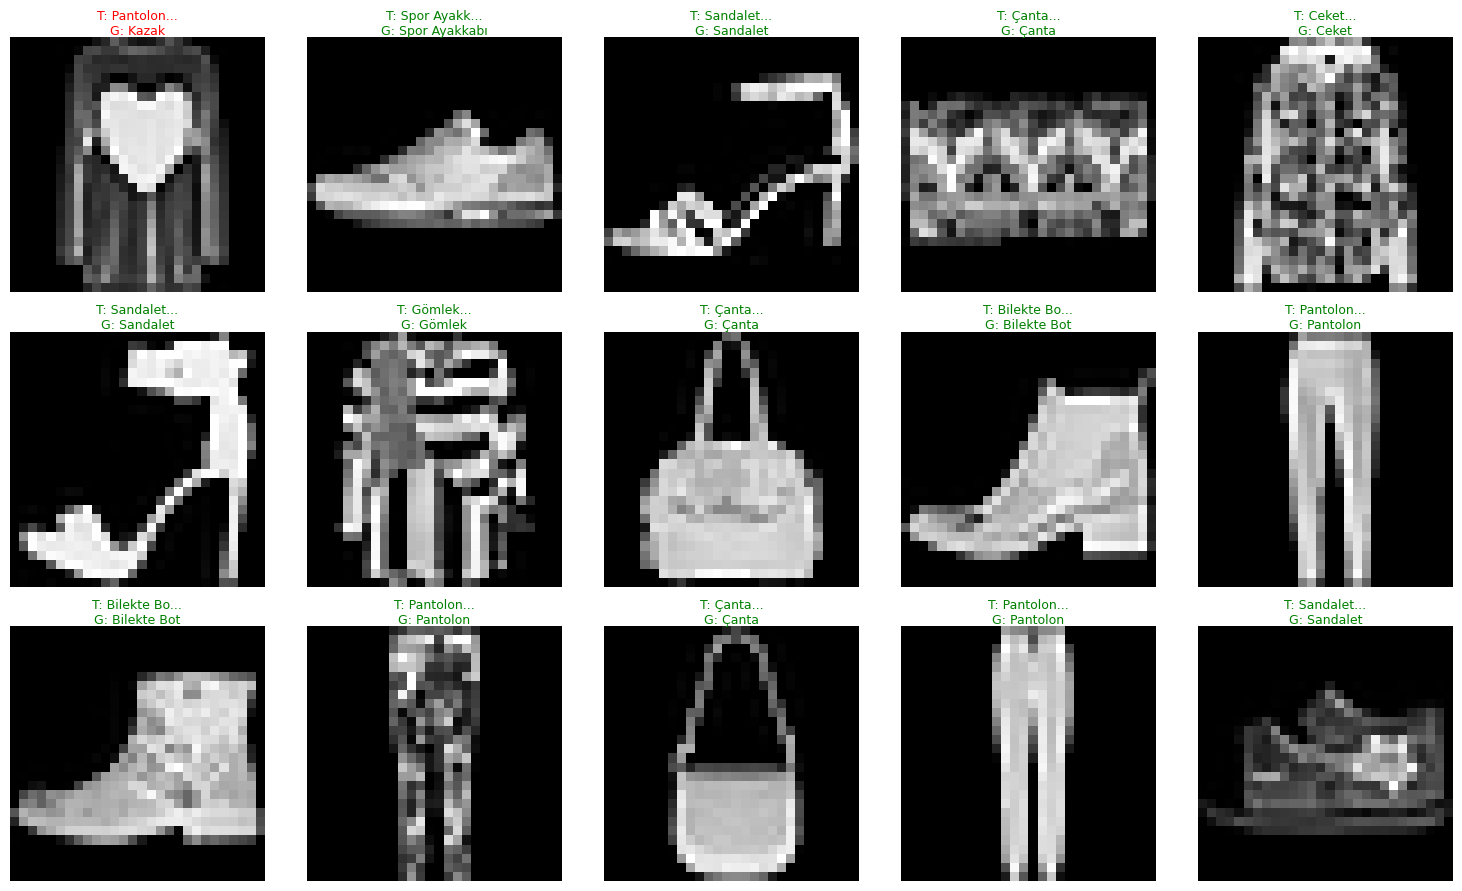

In [17]:
class_names = ['Tişört/Üst', 'Pantolon', 'Kazak', 'Elbise', 'Ceket',
               'Sandalet', 'Gömlek', 'Spor Ayakkabı', 'Çanta', 'Bilekte Bot']

last_15_images = test_images[-15:].reshape(15, 28, 28)
last_15_labels = true_labels[-15:]
last_15_predictions = predictions[-15:]

plt.figure(figsize=(15, 9))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(last_15_images[i], cmap='gray')
    pred_name = class_names[last_15_predictions[i]]
    true_name = class_names[last_15_labels[i]]
    color = 'green' if last_15_predictions[i] == last_15_labels[i] else 'red'
    plt.title(f"T: {pred_name[:10]}...\nG: {true_name}", color=color, fontsize=9, pad=2)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [20]:
print("\nSon 15 Tahmin Sonucu:")
for i in range(15):
    status = "Doğru Tahmin : " if last_15_predictions[i] == last_15_labels[i] else "Yanlış Tahmin : "
    print(f"Resim {i+1:2}: {status} {class_names[last_15_labels[i]]} → {class_names[last_15_predictions[i]]}")



Son 15 Tahmin Sonucu:
Resim  1: Yanlış Tahmin :  Kazak → Pantolon
Resim  2: Doğru Tahmin :  Spor Ayakkabı → Spor Ayakkabı
Resim  3: Doğru Tahmin :  Sandalet → Sandalet
Resim  4: Doğru Tahmin :  Çanta → Çanta
Resim  5: Doğru Tahmin :  Ceket → Ceket
Resim  6: Doğru Tahmin :  Sandalet → Sandalet
Resim  7: Doğru Tahmin :  Gömlek → Gömlek
Resim  8: Doğru Tahmin :  Çanta → Çanta
Resim  9: Doğru Tahmin :  Bilekte Bot → Bilekte Bot
Resim 10: Doğru Tahmin :  Pantolon → Pantolon
Resim 11: Doğru Tahmin :  Bilekte Bot → Bilekte Bot
Resim 12: Doğru Tahmin :  Pantolon → Pantolon
Resim 13: Doğru Tahmin :  Çanta → Çanta
Resim 14: Doğru Tahmin :  Pantolon → Pantolon
Resim 15: Doğru Tahmin :  Sandalet → Sandalet
